# Visualização simples das features FastF1 por circuito

Este notebook serve apenas para visualizar o arquivo:

```text
data/processed/features_fastf1_por_circuito.csv
```

Ele mostra:
- a tabela completa;
- uma versão colorida da tabela;
- gráficos simples por feature.


In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)


## 1. Encontrar a raiz do projeto e carregar o CSV

In [11]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for path in [start, *start.parents]:
        if (path / "data").exists():
            return path

    raise FileNotFoundError("Não encontrei a pasta data/. Abra o notebook pela raiz do projeto ou pela pasta notebooks/.")


ROOT = find_project_root()
features_path = ROOT / "data" / "processed" / "features_fastf1_por_circuito.csv"

df = pd.read_csv(features_path, index_col=0)
df.index.name = "circuito"

print(f"Arquivo carregado: {features_path}")
print(f"Linhas: {len(df)}")
print(f"Colunas: {len(df.columns)}")

df


Arquivo carregado: /home/livcras/Monografia-f1/data/processed/features_fastf1_por_circuito.csv
Linhas: 26
Colunas: 10


,vel_media,vel_minima,pct_baixa_vel,pct_full_throttle,pct_freando,zonas_freio,pico_desac,pico_acel,temp_pista,n_curvas
circuito,,,,,,,,,,
Austin,208.869565,82.000,17.268041,57.348703,18.414322,10.0,-32.870370,14.016204,37.900,20
Baku,209.581267,80.220,19.437340,60.401003,19.714964,11.0,-32.543003,14.739859,32.475,20
Barcelona,218.082540,93.000,7.120743,62.815884,16.037736,8.0,-29.783951,12.731481,36.250,16
Budapest,204.981884,99.160,7.885305,54.193548,19.937695,11.0,-30.092593,12.731481,41.000,16
Imola,233.966461,109.040,3.839734,69.713515,15.685897,9.0,-30.092593,12.731481,33.175,19
Jeddah,247.838906,95.660,5.405405,72.594752,12.383901,8.0,-31.435185,12.731481,31.275,27
Las Vegas,234.515557,91.000,16.334948,64.174187,17.223551,8.0,-31.046131,13.063908,13.950,17
Le Castellet,227.873351,86.760,7.754011,60.433604,16.402116,11.0,-26.620370,12.764550,44.400,15
Lusail,237.280059,104.010,2.631579,67.706285,13.552189,8.0,-23.164683,11.574074,27.375,16


## 2. Tabela arredondada

In [12]:
df_round = df.round(1)
df_round


,vel_media,vel_minima,pct_baixa_vel,pct_full_throttle,pct_freando,zonas_freio,pico_desac,pico_acel,temp_pista,n_curvas
circuito,,,,,,,,,,
Austin,208.9,82.0,17.3,57.3,18.4,10.0,-32.9,14.0,37.9,20
Baku,209.6,80.2,19.4,60.4,19.7,11.0,-32.5,14.7,32.5,20
Barcelona,218.1,93.0,7.1,62.8,16.0,8.0,-29.8,12.7,36.2,16
Budapest,205.0,99.2,7.9,54.2,19.9,11.0,-30.1,12.7,41.0,16
Imola,234.0,109.0,3.8,69.7,15.7,9.0,-30.1,12.7,33.2,19
Jeddah,247.8,95.7,5.4,72.6,12.4,8.0,-31.4,12.7,31.3,27
Las Vegas,234.5,91.0,16.3,64.2,17.2,8.0,-31.0,13.1,14.0,17
Le Castellet,227.9,86.8,7.8,60.4,16.4,11.0,-26.6,12.8,44.4,15
Lusail,237.3,104.0,2.6,67.7,13.6,8.0,-23.2,11.6,27.4,16


## 3. Ranking por feature

Escolha uma feature e veja os circuitos ordenados por ela.


In [14]:
# Troque aqui pela feature que quiser visualizar
feature = "vel_media"

df_round[[feature]].sort_values(feature, ascending=False)


,vel_media
circuito,
Monza,258.1
Jeddah,247.8
Silverstone,241.8
Melbourne,241.3
Spielberg,239.2
Spa-Francorchamps,239.1
Lusail,237.3
Las Vegas,234.5
Imola,234.0


## 4. Correlação simples entre as features

Opcional, mas útil para ver quais variáveis caminham juntas.


In [15]:
corr = df.corr(numeric_only=True).round(2)
corr


,vel_media,vel_minima,pct_baixa_vel,pct_full_throttle,pct_freando,zonas_freio,pico_desac,pico_acel,temp_pista,n_curvas
vel_media,1.00,0.49,-0.76,0.94,-0.96,-0.73,0.09,-0.57,-0.29,-0.21
vel_minima,0.49,1.00,-0.75,0.52,-0.50,-0.22,0.46,-0.77,-0.33,-0.00
pct_baixa_vel,-0.76,-0.75,1.00,-0.80,0.79,0.50,-0.33,0.78,0.20,0.21
pct_full_throttle,0.94,0.52,-0.80,1.00,-0.92,-0.72,0.06,-0.49,-0.30,-0.16
pct_freando,-0.96,-0.50,0.79,-0.92,1.00,0.70,-0.18,0.63,0.29,0.11
zonas_freio,-0.73,-0.22,0.50,-0.72,0.70,1.00,0.13,0.42,0.15,0.40
pico_desac,0.09,0.46,-0.33,0.06,-0.18,0.13,1.00,-0.53,-0.29,0.06
pico_acel,-0.57,-0.77,0.78,-0.49,0.63,0.42,-0.53,1.00,0.32,0.13
temp_pista,-0.29,-0.33,0.20,-0.30,0.29,0.15,-0.29,0.32,1.00,-0.31
n_curvas,-0.21,-0.00,0.21,-0.16,0.11,0.40,0.06,0.13,-0.31,1.00


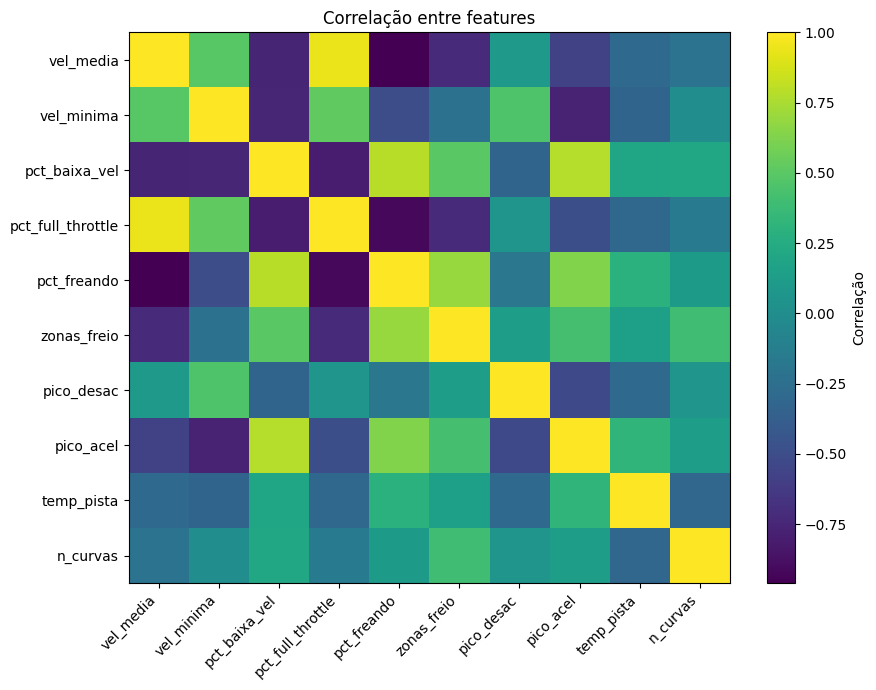

In [16]:
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

plt.title("Correlação entre features")
plt.tight_layout()
plt.show()
